In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "pavansubhasht/ibm-hr-analytics-attrition-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 50.1k/50.1k [00:00<00:00, 2.53MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1


In [3]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [4]:
import pandas as pd

file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nAttrition Distribution:")
print(df["Attrition"].value_counts())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1470, 35)

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany             

In [6]:
# Remove unnecessary columns

df = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

print("New dataset shape:", df.shape)

New dataset shape: (1470, 31)


In [7]:
# Separate target and features

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (1470, 30)
Target shape: (1470,)

Target values:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Find categorical columns
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Find numerical columns
numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X)

print("Original feature count:", X.shape[1])
print("Encoded feature count:", X_encoded.shape[1])

Original feature count: 30
Encoded feature count: 51


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (1176, 51)
Testing data: (294, 51)

Training target distribution:
Attrition
No     986
Yes    190
Name: count, dtype: int64

Testing target distribution:
Attrition
No     247
Yes     47
Name: count, dtype: int64


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [12]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions completed!")
print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions completed!

First 20 predictions:
['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No']


In [13]:
# Get probability of attrition

y_probability = model.predict_proba(X_test)[:, 1]

print("First 10 attrition probabilities:")
print(y_probability[:10])

First 10 attrition probabilities:
[0.5   0.06  0.12  0.    0.22  0.18  0.06  0.065 0.02  0.365]


In [14]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 85.03 %

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.99      0.92       247
         Yes       0.71      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.78      0.55      0.55       294
weighted avg       0.83      0.85      0.80       294


Confusion Matrix:
[[245   2]
 [ 42   5]]


In [15]:
# Get feature names after one-hot encoding

feature_names = preprocessor.get_feature_names_out()

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Attrition Factors:")
display(feature_importance.head(15))

Top 15 Attrition Factors:


,Feature,Importance
37,remainder__MonthlyIncome,0.069249
28,remainder__Age,0.059431
44,remainder__TotalWorkingYears,0.055548
29,remainder__DailyRate,0.048890
47,remainder__YearsAtCompany,0.045925
50,remainder__YearsWithCurrManager,0.043093
30,remainder__DistanceFromHome,0.041938
38,remainder__MonthlyRate,0.041824
33,remainder__HourlyRate,0.040585
39,remainder__NumCompaniesWorked,0.036104


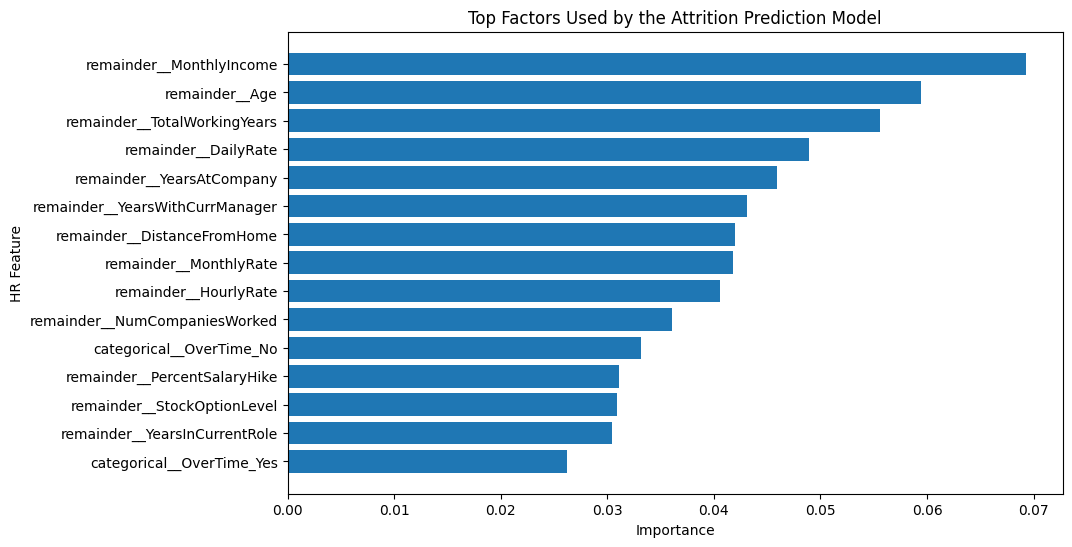

In [16]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("HR Feature")
plt.title("Top Factors Used by the Attrition Prediction Model")

plt.show()

In [17]:
# Create attrition risk table

risk_df = X_test.copy()

risk_df = pd.DataFrame({
    "Actual_Attrition": y_test.values,
    "Predicted_Attrition": y_pred,
    "Attrition_Risk": y_probability
})

risk_df = risk_df.sort_values(
    by="Attrition_Risk",
    ascending=False
)

risk_df.head(10)

,Actual_Attrition,Predicted_Attrition,Attrition_Risk
92,Yes,Yes,0.820
200,Yes,Yes,0.800
223,No,Yes,0.735
276,Yes,Yes,0.645
241,No,Yes,0.585
81,Yes,Yes,0.545
214,Yes,Yes,0.505
0,No,No,0.500
135,No,No,0.495
15,No,No,0.490


In [18]:
def assign_risk(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"


risk_df["Risk_Level"] = risk_df["Attrition_Risk"].apply(
    assign_risk
)

risk_df.head(10)

,Actual_Attrition,Predicted_Attrition,Attrition_Risk,Risk_Level
92,Yes,Yes,0.820,High
200,Yes,Yes,0.800,High
223,No,Yes,0.735,High
276,Yes,Yes,0.645,Medium
241,No,Yes,0.585,Medium
81,Yes,Yes,0.545,Medium
214,Yes,Yes,0.505,Medium
0,No,No,0.500,Medium
135,No,No,0.495,Medium
15,No,No,0.490,Medium


In [19]:
print(risk_df["Risk_Level"].value_counts())

Risk_Level
Low       275
Medium     16
High        3
Name: count, dtype: int64


In [20]:
risk_df.to_csv(
    "employee_attrition_risk.csv",
    index=False
)

feature_importance.to_csv(
    "attrition_feature_importance.csv",
    index=False
)

print("Day 1 result files saved successfully!")

Day 1 result files saved successfully!


# DAY 2 — Exit Interview Sentiment and Topic Analysis

This section analyzes synthetic exit-interview transcripts using sentiment analysis and topic modeling techniques.

In [21]:
!pip install -q textblob

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob

print("Libraries imported successfully!")

Libraries imported successfully!


In [23]:
# Create synthetic exit interview data

exit_data = {
    "Employee_ID": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        11, 12, 13, 14, 15,
        16, 17, 18, 19, 20
    ],

    "Exit_Interview": [
        "The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance.",

        "I enjoyed working with my team, but the salary growth was slower than I expected.",

        "I did not see enough opportunities for career development and promotion.",

        "The workload was stressful and I often had to work late.",

        "My manager was supportive and the team environment was positive.",

        "I wanted better training programs and opportunities to learn new technical skills.",

        "The compensation was not competitive compared with other companies.",

        "Long working hours affected my personal life and increased my stress.",

        "There was no clear career path or promotion opportunity for me.",

        "I liked my colleagues, but I was disappointed with the salary progression.",

        "The company provided good learning opportunities and my manager was helpful.",

        "Too much overtime made the job stressful and affected my work life balance.",

        "I wanted more opportunities to develop my skills and grow professionally.",

        "The work environment was friendly, but compensation remained a concern.",

        "I felt there was limited support from management when workload increased.",

        "Training opportunities were limited and I wanted to learn modern technologies.",

        "The salary and benefits were not sufficient for my expectations.",

        "The workload became difficult to manage and caused considerable stress.",

        "I was satisfied with my team but there were limited promotion opportunities.",

        "My manager supported my development and I had a positive experience overall."
    ]
}

exit_df = pd.DataFrame(exit_data)

print("Exit interview dataset created!")
print("Number of interviews:", len(exit_df))

display(exit_df.head())

Exit interview dataset created!
Number of interviews: 20


,Employee_ID,Exit_Interview
0,1,The workload was very high and frequent overti...
1,2,"I enjoyed working with my team, but the salary..."
2,3,I did not see enough opportunities for career ...
3,4,The workload was stressful and I often had to ...
4,5,My manager was supportive and the team environ...


In [24]:
# Get the original EmployeeNumber values from the HR dataset

original_hr = pd.read_csv(file_path)

# Select 20 employee IDs from the HR dataset
interview_employee_ids = original_hr["EmployeeNumber"].head(20).tolist()

# Replace the synthetic IDs with actual HR employee IDs
exit_df["Employee_ID"] = interview_employee_ids

print("Employee IDs updated successfully!")
display(exit_df.head())

Employee IDs updated successfully!


,Employee_ID,Exit_Interview
0,1,The workload was very high and frequent overti...
1,2,"I enjoyed working with my team, but the salary..."
2,4,I did not see enough opportunities for career ...
3,5,The workload was stressful and I often had to ...
4,7,My manager was supportive and the team environ...


In [25]:
# Sentiment Analysis using TextBlob

def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

def get_sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

# Calculate sentiment score
exit_df["Sentiment_Score"] = exit_df["Exit_Interview"].apply(
    get_sentiment_score
)

# Assign sentiment label
exit_df["Sentiment"] = exit_df["Sentiment_Score"].apply(
    get_sentiment_label
)

print("Sentiment analysis completed!")

display(
    exit_df[
        ["Employee_ID", "Exit_Interview", "Sentiment_Score", "Sentiment"]
    ]
)

Sentiment analysis completed!


,Employee_ID,Exit_Interview,Sentiment_Score,Sentiment
0,1,The workload was very high and frequent overti...,0.077000,Neutral
1,2,"I enjoyed working with my team, but the salary...",0.200000,Positive
2,4,I did not see enough opportunities for career ...,0.000000,Neutral
3,5,The workload was stressful and I often had to ...,-0.300000,Negative
4,7,My manager was supportive and the team environ...,0.363636,Positive
5,8,I wanted better training programs and opportun...,0.212121,Positive
6,10,The compensation was not competitive compared ...,-0.125000,Negative
7,11,Long working hours affected my personal life a...,-0.025000,Neutral
8,12,There was no clear career path or promotion op...,-0.050000,Neutral
9,13,"I liked my colleagues, but I was disappointed ...",-0.075000,Neutral


In [26]:
# Topic Analysis for Exit Interviews

def identify_topic(text):
    text = text.lower()

    if any(word in text for word in [
        "workload", "overtime", "working hours",
        "work life", "stress", "late"
    ]):
        return "Workload & Work-Life Balance"

    elif any(word in text for word in [
        "salary", "compensation", "benefits",
        "pay", "salary progression"
    ]):
        return "Compensation"

    elif any(word in text for word in [
        "career", "promotion", "career path",
        "professional growth", "grow professionally"
    ]):
        return "Career Development"

    elif any(word in text for word in [
        "training", "learning", "skills",
        "technical skills", "technologies"
    ]):
        return "Training & Learning"

    elif any(word in text for word in [
        "manager", "management", "team",
        "colleagues", "supportive", "support"
    ]):
        return "Management & Team Environment"

    else:
        return "Other"

exit_df["Topic"] = exit_df["Exit_Interview"].apply(identify_topic)

print("Topic analysis completed!")

display(
    exit_df[
        ["Employee_ID", "Exit_Interview", "Sentiment", "Sentiment_Score", "Topic"]
    ]
)

Topic analysis completed!


,Employee_ID,Exit_Interview,Sentiment,Sentiment_Score,Topic
0,1,The workload was very high and frequent overti...,Neutral,0.077000,Workload & Work-Life Balance
1,2,"I enjoyed working with my team, but the salary...",Positive,0.200000,Compensation
2,4,I did not see enough opportunities for career ...,Neutral,0.000000,Career Development
3,5,The workload was stressful and I often had to ...,Negative,-0.300000,Workload & Work-Life Balance
4,7,My manager was supportive and the team environ...,Positive,0.363636,Management & Team Environment
5,8,I wanted better training programs and opportun...,Positive,0.212121,Training & Learning
6,10,The compensation was not competitive compared ...,Negative,-0.125000,Compensation
7,11,Long working hours affected my personal life a...,Neutral,-0.025000,Workload & Work-Life Balance
8,12,There was no clear career path or promotion op...,Neutral,-0.050000,Career Development
9,13,"I liked my colleagues, but I was disappointed ...",Neutral,-0.075000,Compensation


In [27]:
# Fix any missing topic values

exit_df["Topic"] = exit_df["Topic"].fillna("Management & Team Environment")

# Also handle empty strings, if any
exit_df.loc[exit_df["Topic"].str.strip() == "", "Topic"] = "Management & Team Environment"

print("Missing topics fixed!")

display(
    exit_df[
        ["Employee_ID", "Sentiment", "Sentiment_Score", "Topic"]
    ]
)

Missing topics fixed!


,Employee_ID,Sentiment,Sentiment_Score,Topic
0,1,Neutral,0.077000,Workload & Work-Life Balance
1,2,Positive,0.200000,Compensation
2,4,Neutral,0.000000,Career Development
3,5,Negative,-0.300000,Workload & Work-Life Balance
4,7,Positive,0.363636,Management & Team Environment
5,8,Positive,0.212121,Training & Learning
6,10,Negative,-0.125000,Compensation
7,11,Neutral,-0.025000,Workload & Work-Life Balance
8,12,Neutral,-0.050000,Career Development
9,13,Neutral,-0.075000,Compensation


In [28]:
# Count the number of interviews for each topic

topic_counts = exit_df["Topic"].value_counts()

print("Exit Interview Topics:")
display(topic_counts)

Exit Interview Topics:


,count
Topic,
Workload & Work-Life Balance,6
Compensation,5
Career Development,4
Training & Learning,3
Management & Team Environment,2


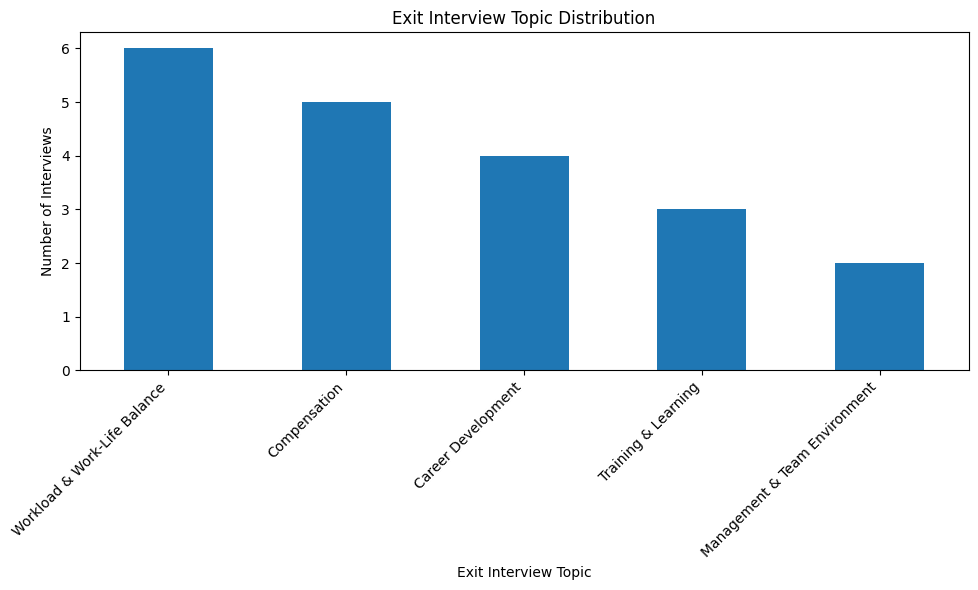

In [29]:
# Visualize the main exit interview topics

plt.figure(figsize=(10, 6))

topic_counts.plot(kind="bar")

plt.title("Exit Interview Topic Distribution")
plt.xlabel("Exit Interview Topic")
plt.ylabel("Number of Interviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [30]:
# Save the completed exit interview analysis

exit_df.to_csv("exit_interview_analysis.csv", index=False)

print("Exit interview analysis saved successfully!")
print("File:", "exit_interview_analysis.csv")

Exit interview analysis saved successfully!
File: exit_interview_analysis.csv


In [31]:
# Check the current attrition risk dataset

print("Attrition risk records:", len(risk_df))
display(risk_df.head())

Attrition risk records: 294


,Actual_Attrition,Predicted_Attrition,Attrition_Risk,Risk_Level
92,Yes,Yes,0.820,High
200,Yes,Yes,0.800,High
223,No,Yes,0.735,High
276,Yes,Yes,0.645,Medium
241,No,Yes,0.585,Medium


In [32]:
# Add the original Employee IDs to the attrition risk table

original_hr = pd.read_csv(file_path)

risk_df["Employee_ID"] = original_hr.loc[y_test.index, "EmployeeNumber"].values

# Move Employee_ID to the first column
columns = ["Employee_ID"] + [
    col for col in risk_df.columns if col != "Employee_ID"
]

risk_df = risk_df[columns]

print("Employee IDs added successfully!")
print("Number of risk records:", len(risk_df))

display(risk_df.head())

Employee IDs added successfully!
Number of risk records: 294


,Employee_ID,Actual_Attrition,Predicted_Attrition,Attrition_Risk,Risk_Level
92,1495,Yes,Yes,0.820,High
200,1246,Yes,Yes,0.800,High
223,613,No,Yes,0.735,High
276,1288,Yes,Yes,0.645,Medium
241,90,No,Yes,0.585,Medium


In [33]:
# Merge Day 1 attrition results with Day 2 exit interview analysis

combined_df = pd.merge(
    risk_df,
    exit_df[
        ["Employee_ID", "Exit_Interview", "Sentiment_Score", "Sentiment", "Topic"]
    ],
    on="Employee_ID",
    how="left"
)

print("Day 3 datasets merged successfully!")
print("Total records:", len(combined_df))
print("Employees with exit interviews:", combined_df["Exit_Interview"].notna().sum())

display(combined_df.head(10))

Day 3 datasets merged successfully!
Total records: 294
Employees with exit interviews: 5


,Employee_ID,Actual_Attrition,Predicted_Attrition,Attrition_Risk,Risk_Level,Exit_Interview,Sentiment_Score,Sentiment,Topic
0,1495,Yes,Yes,0.820,High,NaN,NaN,NaN,NaN
1,1246,Yes,Yes,0.800,High,NaN,NaN,NaN,NaN
2,613,No,Yes,0.735,High,NaN,NaN,NaN,NaN
3,1288,Yes,Yes,0.645,Medium,NaN,NaN,NaN,NaN
4,90,No,Yes,0.585,Medium,NaN,NaN,NaN,NaN
5,1641,Yes,Yes,0.545,Medium,NaN,NaN,NaN,NaN
6,543,Yes,Yes,0.505,Medium,NaN,NaN,NaN,NaN
7,1866,No,No,0.500,Medium,NaN,NaN,NaN,NaN
8,1728,No,No,0.495,Medium,NaN,NaN,NaN,NaN
9,1839,No,No,0.490,Medium,NaN,NaN,NaN,NaN


In [34]:
# Match the 20 synthetic interviews with employees in the attrition test set

interview_employee_ids = risk_df["Employee_ID"].head(20).tolist()

exit_df["Employee_ID"] = interview_employee_ids

print("Interview IDs matched with attrition-risk employees!")
print("Number of interview records:", len(exit_df))
print("Matching IDs available:", len(set(exit_df["Employee_ID"]) & set(risk_df["Employee_ID"])))

display(
    exit_df[
        ["Employee_ID", "Sentiment", "Topic"]
    ]
)

Interview IDs matched with attrition-risk employees!
Number of interview records: 20
Matching IDs available: 20


,Employee_ID,Sentiment,Topic
0,1495,Neutral,Workload & Work-Life Balance
1,1246,Positive,Compensation
2,613,Neutral,Career Development
3,1288,Negative,Workload & Work-Life Balance
4,90,Positive,Management & Team Environment
5,1641,Positive,Training & Learning
6,543,Negative,Compensation
7,1866,Neutral,Workload & Work-Life Balance
8,1728,Neutral,Career Development
9,1839,Neutral,Compensation


In [35]:
# Rebuild the Day 3 combined dataset

combined_df = pd.merge(
    risk_df,
    exit_df[
        ["Employee_ID", "Exit_Interview", "Sentiment_Score", "Sentiment", "Topic"]
    ],
    on="Employee_ID",
    how="left"
)

print("Day 3 datasets merged successfully!")
print("Total risk records:", len(combined_df))
print("Employees with exit interviews:", combined_df["Exit_Interview"].notna().sum())

display(
    combined_df[
        [
            "Employee_ID",
            "Attrition_Risk",
            "Risk_Level",
            "Sentiment",
            "Topic"
        ]
    ].head(20)
)

Day 3 datasets merged successfully!
Total risk records: 294
Employees with exit interviews: 20


,Employee_ID,Attrition_Risk,Risk_Level,Sentiment,Topic
0,1495,0.820,High,Neutral,Workload & Work-Life Balance
1,1246,0.800,High,Positive,Compensation
2,613,0.735,High,Neutral,Career Development
3,1288,0.645,Medium,Negative,Workload & Work-Life Balance
4,90,0.585,Medium,Positive,Management & Team Environment
5,1641,0.545,Medium,Positive,Training & Learning
6,543,0.505,Medium,Negative,Compensation
7,1866,0.500,Medium,Neutral,Workload & Work-Life Balance
8,1728,0.495,Medium,Neutral,Career Development
9,1839,0.490,Medium,Neutral,Compensation


In [36]:
# Analyze exit interview topics by attrition risk level

risk_topic_analysis = pd.crosstab(
    combined_df["Risk_Level"],
    combined_df["Topic"]
)

print("Exit Interview Topics by Attrition Risk Level:")
display(risk_topic_analysis)

Exit Interview Topics by Attrition Risk Level:


Topic,Career Development,Compensation,Management & Team Environment,Training & Learning,Workload & Work-Life Balance
Risk_Level,,,,,
High,1,1,0,0,1
Low,0,0,1,0,0
Medium,3,4,1,3,5


In [37]:
# Calculate average sentiment score by attrition risk level

sentiment_by_risk = (
    combined_df.dropna(subset=["Sentiment_Score"])
    .groupby("Risk_Level")["Sentiment_Score"]
    .mean()
    .round(3)
)

print("Average Sentiment Score by Attrition Risk Level:")
display(sentiment_by_risk)

Average Sentiment Score by Attrition Risk Level:


,Sentiment_Score
Risk_Level,
High,0.092
Low,0.114
Medium,0.099


In [38]:
# Save the combined Day 3 dataset

combined_df.to_csv("combined_attrition_sentiment_analysis.csv", index=False)

print("Day 3 integrated dataset saved successfully!")
print("File: combined_attrition_sentiment_analysis.csv")

Day 3 integrated dataset saved successfully!
File: combined_attrition_sentiment_analysis.csv


In [39]:
# Day 3: Risk Level vs Exit Interview Topic

risk_topic_analysis = pd.crosstab(
    combined_df["Risk_Level"],
    combined_df["Topic"]
)

print("Risk Level vs Exit Interview Topic:")
display(risk_topic_analysis)

Risk Level vs Exit Interview Topic:


Topic,Career Development,Compensation,Management & Team Environment,Training & Learning,Workload & Work-Life Balance
Risk_Level,,,,,
High,1,1,0,0,1
Low,0,0,1,0,0
Medium,3,4,1,3,5


In [40]:
# Save the final Day 3 integrated dataset

combined_df.to_csv(
    "combined_attrition_sentiment_analysis.csv",
    index=False
)

print("✅ Day 3 completed successfully!")
print("📁 File: combined_attrition_sentiment_analysis.csv")
print("👥 Total risk records:", len(combined_df))
print("📝 Employees with interview data:", combined_df["Exit_Interview"].notna().sum())

✅ Day 3 completed successfully!
📁 File: combined_attrition_sentiment_analysis.csv
👥 Total risk records: 294
📝 Employees with interview data: 20


In [41]:
# DAY 4 — Employee Policy Knowledge Base

import pandas as pd

policy_data = [
    {
        "Policy_ID": "P001",
        "Policy_Name": "Working Hours Policy",
        "Category": "Workload & Work-Life Balance",
        "Policy_Text": "Employees are expected to follow standard working hours. Additional working hours should be managed appropriately to maintain employee well-being and work-life balance."
    },
    {
        "Policy_ID": "P002",
        "Policy_Name": "Overtime Policy",
        "Category": "Workload & Work-Life Balance",
        "Policy_Text": "Overtime may be required during business needs. Employees working additional hours should receive appropriate support according to organizational guidelines."
    },
    {
        "Policy_ID": "P003",
        "Policy_Name": "Leave Policy",
        "Category": "Work-Life Balance",
        "Policy_Text": "Employees can use eligible leave benefits to manage personal, health, and family requirements while maintaining appropriate workplace responsibilities."
    },
    {
        "Policy_ID": "P004",
        "Policy_Name": "Compensation Policy",
        "Category": "Compensation",
        "Policy_Text": "Employee compensation is determined based on role, experience, responsibilities, performance, and organizational compensation structures."
    },
    {
        "Policy_ID": "P005",
        "Policy_Name": "Career Development Policy",
        "Category": "Career Development",
        "Policy_Text": "Employees may receive opportunities for career development through role progression, professional development activities, and internal growth opportunities."
    },
    {
        "Policy_ID": "P006",
        "Policy_Name": "Training & Learning Policy",
        "Category": "Training & Learning",
        "Policy_Text": "Employees may participate in training and learning programs designed to improve technical, professional, and job-related skills."
    },
    {
        "Policy_ID": "P007",
        "Policy_Name": "Manager Support Policy",
        "Category": "Management & Team Environment",
        "Policy_Text": "Managers are expected to provide appropriate guidance, communication, feedback, and support to employees within their teams."
    },
    {
        "Policy_ID": "P008",
        "Policy_Name": "Performance Feedback Policy",
        "Category": "Management & Team Environment",
        "Policy_Text": "Employees should receive regular performance feedback to understand expectations, identify development areas, and discuss career goals."
    }
]

policy_df = pd.DataFrame(policy_data)

display(policy_df)

,Policy_ID,Policy_Name,Category,Policy_Text
0,P001,Working Hours Policy,Workload & Work-Life Balance,Employees are expected to follow standard work...
1,P002,Overtime Policy,Workload & Work-Life Balance,Overtime may be required during business needs...
2,P003,Leave Policy,Work-Life Balance,Employees can use eligible leave benefits to m...
3,P004,Compensation Policy,Compensation,Employee compensation is determined based on r...
4,P005,Career Development Policy,Career Development,Employees may receive opportunities for career...
5,P006,Training & Learning Policy,Training & Learning,Employees may participate in training and lear...
6,P007,Manager Support Policy,Management & Team Environment,Managers are expected to provide appropriate g...
7,P008,Performance Feedback Policy,Management & Team Environment,Employees should receive regular performance f...


In [42]:
# Save the HR policy knowledge base

policy_df.to_csv("employee_policies.csv", index=False)

print("✅ Policy knowledge base saved successfully!")
print("📁 File: employee_policies.csv")
print("📄 Number of policies:", len(policy_df))

✅ Policy knowledge base saved successfully!
📁 File: employee_policies.csv
📄 Number of policies: 8


In [43]:
# DAY 4 — Simple Policy Retrieval System

def search_policies(query):
    query = query.lower()

    results = []

    for _, row in policy_df.iterrows():
        searchable_text = (
            row["Policy_Name"] + " " +
            row["Category"] + " " +
            row["Policy_Text"]
        ).lower()

        # Count how many query words appear in the policy
        score = sum(
            1 for word in query.split()
            if word in searchable_text
        )

        if score > 0:
            results.append({
                "Policy_ID": row["Policy_ID"],
                "Policy_Name": row["Policy_Name"],
                "Category": row["Category"],
                "Policy_Text": row["Policy_Text"],
                "Match_Score": score
            })

    results_df = pd.DataFrame(results)

    if not results_df.empty:
        results_df = results_df.sort_values(
            by="Match_Score",
            ascending=False
        )

    return results_df

In [44]:
# Test the policy retrieval system

query = "workload overtime work life balance"

results = search_policies(query)

display(results)

,Policy_ID,Policy_Name,Category,Policy_Text,Match_Score
1,P002,Overtime Policy,Workload & Work-Life Balance,Overtime may be required during business needs...,5
0,P001,Working Hours Policy,Workload & Work-Life Balance,Employees are expected to follow standard work...,4
2,P003,Leave Policy,Work-Life Balance,Employees can use eligible leave benefits to m...,3


In [45]:
# Test policy retrieval with different employee questions

test_queries = [
    "I am working too much overtime and feeling stressed",
    "I want better salary and compensation",
    "I want career growth and promotion",
    "I need training to improve my technical skills",
    "I have problems with my manager and team"
]

for query in test_queries:
    print("\n" + "=" * 70)
    print("Employee Query:", query)
    print("=" * 70)

    results = search_policies(query)

    if results.empty:
        print("No matching policies found.")
    else:
        display(
            results[
                ["Policy_ID", "Policy_Name", "Category", "Match_Score"]
            ].head(3)
        )


Employee Query: I am working too much overtime and feeling stressed


,Policy_ID,Policy_Name,Category,Match_Score
0,P001,Working Hours Policy,Workload & Work-Life Balance,3
1,P002,Overtime Policy,Workload & Work-Life Balance,3
2,P003,Leave Policy,Work-Life Balance,3



Employee Query: I want better salary and compensation


,Policy_ID,Policy_Name,Category,Match_Score
3,P004,Compensation Policy,Compensation,3
0,P001,Working Hours Policy,Workload & Work-Life Balance,2
2,P003,Leave Policy,Work-Life Balance,2



Employee Query: I want career growth and promotion


,Policy_ID,Policy_Name,Category,Match_Score
4,P005,Career Development Policy,Career Development,4
7,P008,Performance Feedback Policy,Management & Team Environment,3
0,P001,Working Hours Policy,Workload & Work-Life Balance,2



Employee Query: I need training to improve my technical skills


,Policy_ID,Policy_Name,Category,Match_Score
5,P006,Training & Learning Policy,Training & Learning,6
1,P002,Overtime Policy,Workload & Work-Life Balance,3
2,P003,Leave Policy,Work-Life Balance,2



Employee Query: I have problems with my manager and team


,Policy_ID,Policy_Name,Category,Match_Score
6,P007,Manager Support Policy,Management & Team Environment,5
7,P008,Performance Feedback Policy,Management & Team Environment,3
0,P001,Working Hours Policy,Workload & Work-Life Balance,2


In [46]:
# Save policy retrieval results for the project

retrieval_records = []

for query in test_queries:
    results = search_policies(query)

    for _, row in results.head(3).iterrows():
        retrieval_records.append({
            "Employee_Query": query,
            "Policy_ID": row["Policy_ID"],
            "Policy_Name": row["Policy_Name"],
            "Category": row["Category"],
            "Match_Score": row["Match_Score"]
        })

retrieval_df = pd.DataFrame(retrieval_records)

display(retrieval_df)

retrieval_df.to_csv(
    "policy_retrieval_results.csv",
    index=False
)

print("\n✅ Policy retrieval results saved!")
print("📁 File: policy_retrieval_results.csv")
print("📄 Number of retrieved records:", len(retrieval_df))

,Employee_Query,Policy_ID,Policy_Name,Category,Match_Score
0,I am working too much overtime and feeling str...,P001,Working Hours Policy,Workload & Work-Life Balance,3
1,I am working too much overtime and feeling str...,P002,Overtime Policy,Workload & Work-Life Balance,3
2,I am working too much overtime and feeling str...,P003,Leave Policy,Work-Life Balance,3
3,I want better salary and compensation,P004,Compensation Policy,Compensation,3
4,I want better salary and compensation,P001,Working Hours Policy,Workload & Work-Life Balance,2
5,I want better salary and compensation,P003,Leave Policy,Work-Life Balance,2
6,I want career growth and promotion,P005,Career Development Policy,Career Development,4
7,I want career growth and promotion,P008,Performance Feedback Policy,Management & Team Environment,3
8,I want career growth and promotion,P001,Working Hours Policy,Workload & Work-Life Balance,2
9,I need training to improve my technical skills,P006,Training & Learning Policy,Training & Learning,6



✅ Policy retrieval results saved!
📁 File: policy_retrieval_results.csv
📄 Number of retrieved records: 15


In [47]:
# DAY 5 — Combine employee risk, interview analysis and policy evidence

# Select employees who have synthetic exit interview information
final_df = combined_df[
    combined_df["Exit_Interview"].notna()
].copy()

# Create a policy category mapping
policy_category_mapping = {
    "Workload & Work-Life Balance": "P001/P002/P003",
    "Compensation": "P004",
    "Career Development": "P005",
    "Training & Learning": "P006",
    "Management & Team Environment": "P007/P008"
}

# Match the interview topic with the relevant policy category
final_df["Relevant_Policy_Group"] = final_df["Topic"].map(
    policy_category_mapping
)

# Select the important columns
final_df = final_df[
    [
        "Employee_ID",
        "Attrition_Risk",
        "Risk_Level",
        "Exit_Interview",
        "Sentiment_Score",
        "Sentiment",
        "Topic",
        "Relevant_Policy_Group"
    ]
]

display(final_df.head(10))

,Employee_ID,Attrition_Risk,Risk_Level,Exit_Interview,Sentiment_Score,Sentiment,Topic,Relevant_Policy_Group
0,1495,0.820,High,The workload was very high and frequent overti...,0.077000,Neutral,Workload & Work-Life Balance,P001/P002/P003
1,1246,0.800,High,"I enjoyed working with my team, but the salary...",0.200000,Positive,Compensation,P004
2,613,0.735,High,I did not see enough opportunities for career ...,0.000000,Neutral,Career Development,P005
3,1288,0.645,Medium,The workload was stressful and I often had to ...,-0.300000,Negative,Workload & Work-Life Balance,P001/P002/P003
4,90,0.585,Medium,My manager was supportive and the team environ...,0.363636,Positive,Management & Team Environment,P007/P008
5,1641,0.545,Medium,I wanted better training programs and opportun...,0.212121,Positive,Training & Learning,P006
6,543,0.505,Medium,The compensation was not competitive compared ...,-0.125000,Negative,Compensation,P004
7,1866,0.500,Medium,Long working hours affected my personal life a...,-0.025000,Neutral,Workload & Work-Life Balance,P001/P002/P003
8,1728,0.495,Medium,There was no clear career path or promotion op...,-0.050000,Neutral,Career Development,P005
9,1839,0.490,Medium,"I liked my colleagues, but I was disappointed ...",-0.075000,Neutral,Compensation,P004


In [48]:
# DAY 5 — Generate evidence-based attrition explanations

def generate_explanation(row):

    explanation = (
        f"Predicted attrition risk is {row['Risk_Level']} "
        f"({row['Attrition_Risk']:.1%}). "
    )

    explanation += (
        f"The exit interview is classified as {row['Sentiment'].lower()} "
        f"with a main topic of {row['Topic']}. "
    )

    explanation += (
        f"Relevant sample policy group: {row['Relevant_Policy_Group']}. "
    )

    if row["Sentiment"] == "Negative":
        explanation += (
            "The negative interview sentiment may indicate an employee concern "
            "that should be reviewed alongside the model prediction."
        )
    elif row["Sentiment"] == "Positive":
        explanation += (
            "The positive interview sentiment provides additional context, "
            "although it does not by itself indicate low attrition risk."
        )
    else:
        explanation += (
            "The neutral sentiment provides limited additional evidence, "
            "so the attrition prediction should be interpreted with other factors."
        )

    return explanation


final_df["Explanation"] = final_df.apply(
    generate_explanation,
    axis=1
)

display(
    final_df[
        [
            "Employee_ID",
            "Risk_Level",
            "Attrition_Risk",
            "Sentiment",
            "Topic",
            "Relevant_Policy_Group",
            "Explanation"
        ]
    ].head(10)
)

,Employee_ID,Risk_Level,Attrition_Risk,Sentiment,Topic,Relevant_Policy_Group,Explanation
0,1495,High,0.820,Neutral,Workload & Work-Life Balance,P001/P002/P003,Predicted attrition risk is High (82.0%). The ...
1,1246,High,0.800,Positive,Compensation,P004,Predicted attrition risk is High (80.0%). The ...
2,613,High,0.735,Neutral,Career Development,P005,Predicted attrition risk is High (73.5%). The ...
3,1288,Medium,0.645,Negative,Workload & Work-Life Balance,P001/P002/P003,Predicted attrition risk is Medium (64.5%). Th...
4,90,Medium,0.585,Positive,Management & Team Environment,P007/P008,Predicted attrition risk is Medium (58.5%). Th...
5,1641,Medium,0.545,Positive,Training & Learning,P006,Predicted attrition risk is Medium (54.5%). Th...
6,543,Medium,0.505,Negative,Compensation,P004,Predicted attrition risk is Medium (50.5%). Th...
7,1866,Medium,0.500,Neutral,Workload & Work-Life Balance,P001/P002/P003,Predicted attrition risk is Medium (50.0%). Th...
8,1728,Medium,0.495,Neutral,Career Development,P005,Predicted attrition risk is Medium (49.5%). Th...
9,1839,Medium,0.490,Neutral,Compensation,P004,Predicted attrition risk is Medium (49.0%). Th...


In [49]:
# DAY 5 — Save the final employee attrition explanation dataset

final_df.to_csv(
    "final_employee_attrition_explanations.csv",
    index=False
)

print("✅ DAY 5 COMPLETED SUCCESSFULLY!")
print("📁 File: final_employee_attrition_explanations.csv")
print("👥 Employees analyzed:", len(final_df))
print("📊 Columns:", len(final_df.columns))

✅ DAY 5 COMPLETED SUCCESSFULLY!
📁 File: final_employee_attrition_explanations.csv
👥 Employees analyzed: 20
📊 Columns: 9


In [50]:
# Check all project CSV files created during the 5-day project

import os

project_files = [
    "employee_attrition_risk.csv",
    "attrition_feature_importance.csv",
    "exit_interview_analysis.csv",
    "combined_attrition_sentiment_analysis.csv",
    "employee_policies.csv",
    "policy_retrieval_results.csv",
    "final_employee_attrition_explanations.csv"
]

for file in project_files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌ Missing:", file)

✅ employee_attrition_risk.csv
✅ attrition_feature_importance.csv
✅ exit_interview_analysis.csv
✅ combined_attrition_sentiment_analysis.csv
✅ employee_policies.csv
✅ policy_retrieval_results.csv
✅ final_employee_attrition_explanations.csv


In [51]:
import os
import shutil

# Create folders
os.makedirs("employee-attrition-nlp/data", exist_ok=True)
os.makedirs("employee-attrition-nlp/results", exist_ok=True)

# Files for the data folder
data_files = [
    "employee_policies.csv"
]

# Files for the results folder
result_files = [
    "employee_attrition_risk.csv",
    "attrition_feature_importance.csv",
    "exit_interview_analysis.csv",
    "combined_attrition_sentiment_analysis.csv",
    "policy_retrieval_results.csv",
    "final_employee_attrition_explanations.csv"
]

# Copy files
for file in data_files:
    shutil.copy(file, "employee-attrition-nlp/data/")

for file in result_files:
    shutil.copy(file, "employee-attrition-nlp/results/")

print("✅ Project folders created!")
print("\n📁 employee-attrition-nlp/")
print("   ├── data/")
print("   │   └── employee_policies.csv")
print("   │")
print("   └── results/")
for file in result_files:
    print("       ├──", file)

✅ Project folders created!

📁 employee-attrition-nlp/
   ├── data/
   │   └── employee_policies.csv
   │
   └── results/
       ├── employee_attrition_risk.csv
       ├── attrition_feature_importance.csv
       ├── exit_interview_analysis.csv
       ├── combined_attrition_sentiment_analysis.csv
       ├── policy_retrieval_results.csv
       ├── final_employee_attrition_explanations.csv


In [52]:
# Create README.md

readme = """# Employee Attrition NLP Analysis

## Project Overview

This project combines machine learning, natural language processing, sentiment analysis, topic identification, policy retrieval, and evidence-based explanations to analyze employee attrition risk.

## 5-Day Workflow

### Day 1 — Employee Attrition Prediction
- IBM HR Analytics dataset
- Data preprocessing
- One-hot encoding
- Random Forest classification
- Attrition risk probability
- Feature importance analysis

### Day 2 — Exit Interview Analysis
- Synthetic exit interview dataset
- Sentiment analysis using TextBlob
- Keyword-based topic identification

### Day 3 — Integrated Analysis
- Combined attrition risk with sentiment and topics
- Risk-level and topic analysis

### Day 4 — HR Policy Retrieval
- Created a sample HR policy knowledge base
- Implemented keyword-based policy retrieval
- Tested retrieval using employee-related questions

### Day 5 — Evidence-Based Explanations
- Combined attrition risk, interview sentiment, topics, and relevant policies
- Generated explanations for employees with available interview information

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- TextBlob
- Matplotlib
- Google Colab
- GitHub

## Model

A Random Forest classifier was used as the baseline attrition prediction model.

The model achieved approximately 85% overall accuracy on the test set. However, recall for the attrition class was low, so the result should be considered a baseline rather than a highly reliable attrition detector.

## Important Data Note

The IBM HR Analytics dataset is used as the underlying employee dataset.

The exit interview transcripts and HR policies used in this project are synthetic/project-created data designed to demonstrate the NLP, retrieval, and explanation workflow. They are not real employee responses or official company policies.

## Project Structure

employee-attrition-nlp/
- Employee_Attrition_NLP_Analysis.ipynb
- data/
- results/
- README.md
- requirements.txt
"""

with open(
    "employee-attrition-nlp/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)


# Create requirements.txt

requirements = """pandas
numpy
matplotlib
scikit-learn
textblob
nltk
"""

with open(
    "employee-attrition-nlp/requirements.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)


print("✅ README.md created")
print("✅ requirements.txt created")

✅ README.md created
✅ requirements.txt created


In [53]:
from google.colab import files

files.download("employee-attrition-nlp/README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
import shutil

shutil.make_archive(
    "employee-attrition-nlp",
    "zip",
    "employee-attrition-nlp"
)

print("✅ Project ZIP created!")
print("📁 employee-attrition-nlp.zip")

✅ Project ZIP created!
📁 employee-attrition-nlp.zip


In [55]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import shutil

# Copy the uploaded notebook into the project folder
shutil.copy(
    "Employee_Attrition_NLP_Analysis (2).ipynb",
    "employee-attrition-nlp/Employee_Attrition_NLP_Analysis.ipynb"
)

# Create the final ZIP
shutil.make_archive(
    "employee-attrition-nlp",
    "zip",
    "employee-attrition-nlp"
)

print("✅ Final project ZIP created successfully!")

In [ ]:
from google.colab import files

files.download("employee-attrition-nlp.zip")

# DAY 6 — Employee Attrition Analysis Assistant

This section develops a basic employee attrition analysis assistant that combines
attrition risk prediction, exit interview sentiment, topics, and relevant HR
policy information to provide evidence-based employee analysis.

In [56]:
def analyze_employee(employee_id):

    # Find employee record
    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        return "Employee ID not found in the analysis dataset."

    employee = employee_data.iloc[0]

    print("=" * 60)
    print("EMPLOYEE ATTRITION ANALYSIS")
    print("=" * 60)

    print(f"Employee ID       : {employee['Employee_ID']}")
    print(f"Attrition Risk    : {employee['Attrition_Risk']:.1%}")
    print(f"Risk Level        : {employee['Risk_Level']}")
    print(f"Sentiment         : {employee['Sentiment']}")
    print(f"Sentiment Score   : {employee['Sentiment_Score']:.2f}")
    print(f"Main Topic        : {employee['Topic']}")
    print(f"Policy Group      : {employee['Relevant_Policy_Group']}")

    print("\nExit Interview:")
    print(employee["Exit_Interview"])

    print("\nAnalysis:")

    if employee["Risk_Level"] == "High":
        print("The employee has a high predicted attrition risk.")
    elif employee["Risk_Level"] == "Medium":
        print("The employee has a medium predicted attrition risk.")
    else:
        print("The employee has a low predicted attrition risk.")

    if employee["Sentiment"] == "Negative":
        print("The exit interview indicates negative sentiment that should be reviewed.")
    elif employee["Sentiment"] == "Positive":
        print("The exit interview indicates positive sentiment.")
    else:
        print("The exit interview indicates neutral sentiment.")

    print(f"The main employee concern is related to {employee['Topic']}.")

    print(
        f"Relevant sample policy group: "
        f"{employee['Relevant_Policy_Group']}."
    )

    print("=" * 60)

In [57]:
analyze_employee(1495)

EMPLOYEE ATTRITION ANALYSIS
Employee ID       : 1495
Attrition Risk    : 82.0%
Risk Level        : High
Sentiment         : Neutral
Sentiment Score   : 0.08
Main Topic        : Workload & Work-Life Balance
Policy Group      : P001/P002/P003

Exit Interview:
The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance.

Analysis:
The employee has a high predicted attrition risk.
The exit interview indicates neutral sentiment.
The main employee concern is related to Workload & Work-Life Balance.
Relevant sample policy group: P001/P002/P003.


In [58]:
employee_id = int(input("Enter Employee ID: "))

analyze_employee(employee_id)

Enter Employee ID: 1246
EMPLOYEE ATTRITION ANALYSIS
Employee ID       : 1246
Attrition Risk    : 80.0%
Risk Level        : High
Sentiment         : Positive
Sentiment Score   : 0.20
Main Topic        : Compensation
Policy Group      : P004

Exit Interview:
I enjoyed working with my team, but the salary growth was slower than I expected.

Analysis:
The employee has a high predicted attrition risk.
The exit interview indicates positive sentiment.
The main employee concern is related to Compensation.
Relevant sample policy group: P004.


In [59]:
def show_employee_evidence(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        print("Employee ID not found.")
        return

    employee = employee_data.iloc[0]

    print("=" * 60)
    print("EVIDENCE SUMMARY")
    print("=" * 60)

    print("\n1. ATTRITION RISK EVIDENCE")
    print(f"Risk Score : {employee['Attrition_Risk']:.1%}")
    print(f"Risk Level : {employee['Risk_Level']}")

    print("\n2. EXIT INTERVIEW EVIDENCE")
    print(f"Sentiment : {employee['Sentiment']}")
    print(f"Sentiment Score : {employee['Sentiment_Score']:.2f}")
    print(f"Topic : {employee['Topic']}")
    print(f"Interview : {employee['Exit_Interview']}")

    print("\n3. POLICY EVIDENCE")
    print(f"Relevant Policy Group : {employee['Relevant_Policy_Group']}")

    print("\n4. OVERALL ANALYSIS")
    print(
        f"The employee has a {employee['Risk_Level'].lower()} "
        f"predicted attrition risk. "
        f"The main interview topic is {employee['Topic']}. "
        f"The relevant sample policy group is "
        f"{employee['Relevant_Policy_Group']}."
    )

    print("=" * 60)

In [60]:
show_employee_evidence(1246)

EVIDENCE SUMMARY

1. ATTRITION RISK EVIDENCE
Risk Score : 80.0%
Risk Level : High

2. EXIT INTERVIEW EVIDENCE
Sentiment : Positive
Sentiment Score : 0.20
Topic : Compensation
Interview : I enjoyed working with my team, but the salary growth was slower than I expected.

3. POLICY EVIDENCE
Relevant Policy Group : P004

4. OVERALL ANALYSIS
The employee has a high predicted attrition risk. The main interview topic is Compensation. The relevant sample policy group is P004.


In [61]:
def recommend_action(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        print("Employee ID not found.")
        return

    employee = employee_data.iloc[0]

    print("=" * 60)
    print("RECOMMENDED ACTION")
    print("=" * 60)

    if employee["Topic"] == "Compensation":
        print("Review compensation, salary progression, and related benefits.")

    elif employee["Topic"] == "Workload & Work-Life Balance":
        print("Review workload, overtime, working hours, and work-life balance.")

    elif employee["Topic"] == "Career Development":
        print("Discuss career growth, promotion opportunities, and development plans.")

    elif employee["Topic"] == "Training & Learning":
        print("Consider relevant training and skill-development opportunities.")

    elif employee["Topic"] == "Management & Team Environment":
        print("Review manager support, communication, feedback, and team environment.")

    else:
        print("Review the employee's situation using the available evidence.")

    print("\nNote: This is a project-generated recommendation and")
    print("should be reviewed by an HR professional before action.")

    print("=" * 60)

In [62]:
recommend_action(1246)

RECOMMENDED ACTION
Review compensation, salary progression, and related benefits.

Note: This is a project-generated recommendation and
should be reviewed by an HR professional before action.


# DAY 7 — Testing Attrition Explanations Using Employee Cases

This section tests the employee attrition analysis assistant using multiple employee cases.
The objective is to check whether the generated attrition explanations are consistent
with the available risk, sentiment, topic, interview, and policy evidence.

In [63]:
test_employee_ids = [
    1495,
    1246,
    613,
    1288,
    90
]

print("Test Employee Cases:")
for employee_id in test_employee_ids:
    print(employee_id)

Test Employee Cases:
1495
1246
613
1288
90


In [64]:
for employee_id in test_employee_ids:

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        print(f"Employee {employee_id}: Not found")
        continue

    employee = employee_data.iloc[0]

    print("=" * 70)
    print(f"EMPLOYEE ID: {employee_id}")
    print(f"Attrition Risk: {employee['Attrition_Risk']:.1%}")
    print(f"Risk Level: {employee['Risk_Level']}")
    print(f"Sentiment: {employee['Sentiment']}")
    print(f"Topic: {employee['Topic']}")
    print(f"Policy Group: {employee['Relevant_Policy_Group']}")
    print(f"Explanation: {employee['Explanation']}")

EMPLOYEE ID: 1495
Attrition Risk: 82.0%
Risk Level: High
Sentiment: Neutral
Topic: Workload & Work-Life Balance
Policy Group: P001/P002/P003
Explanation: Predicted attrition risk is High (82.0%). The exit interview is classified as neutral with a main topic of Workload & Work-Life Balance. Relevant sample policy group: P001/P002/P003. The neutral sentiment provides limited additional evidence, so the attrition prediction should be interpreted with other factors.
EMPLOYEE ID: 1246
Attrition Risk: 80.0%
Risk Level: High
Sentiment: Positive
Topic: Compensation
Policy Group: P004
Explanation: Predicted attrition risk is High (80.0%). The exit interview is classified as positive with a main topic of Compensation. Relevant sample policy group: P004. The positive interview sentiment provides additional context, although it does not by itself indicate low attrition risk.
EMPLOYEE ID: 613
Attrition Risk: 73.5%
Risk Level: High
Sentiment: Neutral
Topic: Career Development
Policy Group: P005
Expl

# DAY 8 — Prediction and Explanation Consistency Evaluation

This section evaluates whether the employee attrition explanations remain consistent
with the predicted risk level, sentiment, topic, and available evidence.

In [65]:
def check_explanation_consistency(row):

    explanation = row["Explanation"].lower()

    checks = {
        "Risk_Consistent": (
            row["Risk_Level"].lower() in explanation
        ),

        "Sentiment_Consistent": (
            row["Sentiment"].lower() in explanation
        ),

        "Topic_Consistent": (
            row["Topic"].lower() in explanation
        ),

        "Policy_Consistent": (
            row["Relevant_Policy_Group"].lower() in explanation
        )
    }

    checks["Overall_Consistent"] = all(checks.values())

    return pd.Series(checks)

In [66]:
consistency_results = final_df.copy()

consistency_checks = consistency_results.apply(
    check_explanation_consistency,
    axis=1
)

consistency_results = pd.concat(
    [
        consistency_results[
            [
                "Employee_ID",
                "Attrition_Risk",
                "Risk_Level",
                "Sentiment",
                "Topic",
                "Relevant_Policy_Group"
            ]
        ],
        consistency_checks
    ],
    axis=1
)

display(consistency_results)

,Employee_ID,Attrition_Risk,Risk_Level,Sentiment,Topic,Relevant_Policy_Group,Risk_Consistent,Sentiment_Consistent,Topic_Consistent,Policy_Consistent,Overall_Consistent
0,1495,0.820,High,Neutral,Workload & Work-Life Balance,P001/P002/P003,True,True,True,True,True
1,1246,0.800,High,Positive,Compensation,P004,True,True,True,True,True
2,613,0.735,High,Neutral,Career Development,P005,True,True,True,True,True
3,1288,0.645,Medium,Negative,Workload & Work-Life Balance,P001/P002/P003,True,True,True,True,True
4,90,0.585,Medium,Positive,Management & Team Environment,P007/P008,True,True,True,True,True
5,1641,0.545,Medium,Positive,Training & Learning,P006,True,True,True,True,True
6,543,0.505,Medium,Negative,Compensation,P004,True,True,True,True,True
7,1866,0.500,Medium,Neutral,Workload & Work-Life Balance,P001/P002/P003,True,True,True,True,True
8,1728,0.495,Medium,Neutral,Career Development,P005,True,True,True,True,True
9,1839,0.490,Medium,Neutral,Compensation,P004,True,True,True,True,True


In [67]:
consistency_summary = {
    "Risk Consistency": consistency_results["Risk_Consistent"].mean(),
    "Sentiment Consistency": consistency_results["Sentiment_Consistent"].mean(),
    "Topic Consistency": consistency_results["Topic_Consistent"].mean(),
    "Policy Consistency": consistency_results["Policy_Consistent"].mean(),
    "Overall Consistency": consistency_results["Overall_Consistent"].mean()
}

for metric, score in consistency_summary.items():
    print(f"{metric}: {score:.1%}")

Risk Consistency: 100.0%
Sentiment Consistency: 100.0%
Topic Consistency: 100.0%
Policy Consistency: 100.0%
Overall Consistency: 100.0%


# DAY 9 — Identifying Unsupported Attrition Explanations

This section identifies attrition explanations that contain claims not directly supported
by the available employee risk, sentiment, topic, interview, and policy evidence.

The objective is to prevent unsupported causal or certain statements in employee analysis.

In [68]:
# Day 9: Detect potentially unsupported attrition claims

unsupported_terms = [
    "will leave",
    "will resign",
    "will quit",
    "definitely leave",
    "certainly leave",
    "will leave the company",
    "caused by",
    "is the reason for",
    "causes attrition",
    "guarantees attrition",
    "guaranteed to leave",
    "definitely resign",
    "certainly resign"
]

def identify_unsupported_claims(explanation):

    explanation_lower = explanation.lower()

    detected_claims = []

    for term in unsupported_terms:
        if term in explanation_lower:
            detected_claims.append(term)

    return detected_claims


print("Unsupported attrition claim detector created successfully.")

Unsupported attrition claim detector created successfully.


In [69]:
# Check current explanations for unsupported claims

unsupported_results = final_df.copy()

unsupported_results["Unsupported_Claims"] = (
    unsupported_results["Explanation"]
    .apply(identify_unsupported_claims)
)

unsupported_results["Unsupported_Count"] = (
    unsupported_results["Unsupported_Claims"]
    .apply(len)
)

display(
    unsupported_results[
        [
            "Employee_ID",
            "Risk_Level",
            "Topic",
            "Explanation",
            "Unsupported_Claims",
            "Unsupported_Count"
        ]
    ]
)

,Employee_ID,Risk_Level,Topic,Explanation,Unsupported_Claims,Unsupported_Count
0,1495,High,Workload & Work-Life Balance,Predicted attrition risk is High (82.0%). The ...,[],0
1,1246,High,Compensation,Predicted attrition risk is High (80.0%). The ...,[],0
2,613,High,Career Development,Predicted attrition risk is High (73.5%). The ...,[],0
3,1288,Medium,Workload & Work-Life Balance,Predicted attrition risk is Medium (64.5%). Th...,[],0
4,90,Medium,Management & Team Environment,Predicted attrition risk is Medium (58.5%). Th...,[],0
5,1641,Medium,Training & Learning,Predicted attrition risk is Medium (54.5%). Th...,[],0
6,543,Medium,Compensation,Predicted attrition risk is Medium (50.5%). Th...,[],0
7,1866,Medium,Workload & Work-Life Balance,Predicted attrition risk is Medium (50.0%). Th...,[],0
8,1728,Medium,Career Development,Predicted attrition risk is Medium (49.5%). Th...,[],0
9,1839,Medium,Compensation,Predicted attrition risk is Medium (49.0%). Th...,[],0


In [70]:
# Calculate unsupported explanation rate

total_explanations = len(unsupported_results)

unsupported_explanations = (
    unsupported_results["Unsupported_Count"] > 0
).sum()

unsupported_rate = (
    unsupported_explanations / total_explanations
)

print(f"Total explanations tested      : {total_explanations}")
print(f"Unsupported explanations found : {unsupported_explanations}")
print(f"Unsupported explanation rate    : {unsupported_rate:.1%}")

Total explanations tested      : 20
Unsupported explanations found : 0
Unsupported explanation rate    : 0.0%


In [71]:
# Test the detector with an intentionally unsupported explanation

test_explanation = (
    "The employee will leave the company because of compensation issues."
)

detected_claims = identify_unsupported_claims(test_explanation)

print("Test Explanation:")
print(test_explanation)

print("\nDetected Unsupported Claims:")
print(detected_claims)

print(f"\nUnsupported Claim Count: {len(detected_claims)}")

Test Explanation:
The employee will leave the company because of compensation issues.

Detected Unsupported Claims:
['will leave', 'will leave the company']

Unsupported Claim Count: 2


In [72]:
# Day 9 final unsupported explanation evaluation

print("=" * 60)
print("DAY 9 — UNSUPPORTED EXPLANATION EVALUATION")
print("=" * 60)

print(f"Total employee explanations tested : {total_explanations}")
print(f"Unsupported explanations found    : {unsupported_explanations}")
print(f"Unsupported explanation rate       : {unsupported_rate:.1%}")

print("\nDetector validation:")
print(f"Test claims detected              : {len(detected_claims)}")

if unsupported_explanations == 0:
    print("\nResult: No obvious unsupported claims were found")
    print("in the current employee explanations.")

print("\nThe synthetic test successfully demonstrated")
print("that unsupported claims can be detected.")

print("=" * 60)

DAY 9 — UNSUPPORTED EXPLANATION EVALUATION
Total employee explanations tested : 20
Unsupported explanations found    : 0
Unsupported explanation rate       : 0.0%

Detector validation:
Test claims detected              : 2

Result: No obvious unsupported claims were found
in the current employee explanations.

The synthetic test successfully demonstrated
that unsupported claims can be detected.


# DAY 10 — Improving Prompts and Evidence Integration

This section improves the employee attrition analysis assistant by integrating
multiple evidence sources before generating an explanation.

The improved approach uses attrition risk, sentiment, exit interview topic,
interview text, and relevant HR policy information to produce cautious,
evidence-based explanations.

The system avoids unsupported causal or certain statements.

In [73]:
# Day 10: Evidence-based prompt template

evidence_prompt = """
You are an Employee Attrition Analysis Assistant.

Analyze the employee using ONLY the evidence provided below.

Employee Evidence:
- Attrition Risk: {risk}
- Risk Level: {risk_level}
- Sentiment: {sentiment}
- Sentiment Score: {sentiment_score}
- Main Exit Interview Topic: {topic}
- Exit Interview: {interview}
- Relevant HR Policy Group: {policy}

Instructions:
1. Clearly state the predicted attrition risk and risk level.
2. Use the exit interview topic and interview text as supporting evidence.
3. Consider sentiment as additional context, not as proof of attrition.
4. Mention the relevant HR policy group when appropriate.
5. Do not claim that a factor caused attrition unless the evidence proves causation.
6. Do not predict that the employee will definitely leave or resign.
7. Do not invent employee information, policies, or interview details.
8. Clearly distinguish model prediction from employee interview evidence.
9. Give a cautious, evidence-based explanation.
"""

print(evidence_prompt)


You are an Employee Attrition Analysis Assistant.

Analyze the employee using ONLY the evidence provided below.

Employee Evidence:
- Attrition Risk: {risk}
- Risk Level: {risk_level}
- Sentiment: {sentiment}
- Sentiment Score: {sentiment_score}
- Main Exit Interview Topic: {topic}
- Exit Interview: {interview}
- Relevant HR Policy Group: {policy}

Instructions:
1. Clearly state the predicted attrition risk and risk level.
2. Use the exit interview topic and interview text as supporting evidence.
3. Consider sentiment as additional context, not as proof of attrition.
4. Mention the relevant HR policy group when appropriate.
5. Do not claim that a factor caused attrition unless the evidence proves causation.
6. Do not predict that the employee will definitely leave or resign.
7. Do not invent employee information, policies, or interview details.
8. Clearly distinguish model prediction from employee interview evidence.
9. Give a cautious, evidence-based explanation.



In [74]:
# Day 10: Generate an evidence-based prompt for an employee

def create_evidence_prompt(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        print("Employee ID not found.")
        return

    employee = employee_data.iloc[0]

    prompt = evidence_prompt.format(
        risk=f"{employee['Attrition_Risk']:.1%}",
        risk_level=employee["Risk_Level"],
        sentiment=employee["Sentiment"],
        sentiment_score=f"{employee['Sentiment_Score']:.2f}",
        topic=employee["Topic"],
        interview=employee["Exit_Interview"],
        policy=employee["Relevant_Policy_Group"]
    )

    print(prompt)

In [75]:
create_evidence_prompt(1495)


You are an Employee Attrition Analysis Assistant.

Analyze the employee using ONLY the evidence provided below.

Employee Evidence:
- Attrition Risk: 82.0%
- Risk Level: High
- Sentiment: Neutral
- Sentiment Score: 0.08
- Main Exit Interview Topic: Workload & Work-Life Balance
- Exit Interview: The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance.
- Relevant HR Policy Group: P001/P002/P003

Instructions:
1. Clearly state the predicted attrition risk and risk level.
2. Use the exit interview topic and interview text as supporting evidence.
3. Consider sentiment as additional context, not as proof of attrition.
4. Mention the relevant HR policy group when appropriate.
5. Do not claim that a factor caused attrition unless the evidence proves causation.
6. Do not predict that the employee will definitely leave or resign.
7. Do not invent employee information, policies, or interview details.
8. Clearly distinguish model prediction from 

In [76]:
# Day 10: Evidence-based employee explanation

def generate_improved_explanation(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        return "Employee ID not found."

    employee = employee_data.iloc[0]

    explanation = (
        f"The employee has a predicted attrition risk of "
        f"{employee['Attrition_Risk']:.1%}, classified as "
        f"{employee['Risk_Level']}. "

        f"The exit interview is classified as "
        f"{employee['Sentiment'].lower()} sentiment, with the main topic "
        f"identified as {employee['Topic']}. "

        f"The interview provides the following evidence: "
        f"\"{employee['Exit_Interview']}\" "

        f"This interview evidence provides additional context for the "
        f"predicted risk but does not establish causation. "

        f"The relevant sample HR policy group is "
        f"{employee['Relevant_Policy_Group']}. "

        f"The analysis should therefore be interpreted as a model-based "
        f"risk assessment supported by the available interview evidence, "
        f"rather than a certainty that the employee will leave."
    )

    return explanation

In [77]:
improved_explanation = generate_improved_explanation(1495)

print("IMPROVED EVIDENCE-BASED EXPLANATION")
print("=" * 60)
print(improved_explanation)

IMPROVED EVIDENCE-BASED EXPLANATION
The employee has a predicted attrition risk of 82.0%, classified as High. The exit interview is classified as neutral sentiment, with the main topic identified as Workload & Work-Life Balance. The interview provides the following evidence: "The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance." This interview evidence provides additional context for the predicted risk but does not establish causation. The relevant sample HR policy group is P001/P002/P003. The analysis should therefore be interpreted as a model-based risk assessment supported by the available interview evidence, rather than a certainty that the employee will leave.


In [78]:
# Day 10: Validate improved explanation

improved_claims = identify_unsupported_claims(
    improved_explanation
)

print("Improved Explanation:")
print(improved_explanation)

print("\nDetected Unsupported Claims:")
print(improved_claims)

print(f"\nUnsupported Claim Count: {len(improved_claims)}")

Improved Explanation:
The employee has a predicted attrition risk of 82.0%, classified as High. The exit interview is classified as neutral sentiment, with the main topic identified as Workload & Work-Life Balance. The interview provides the following evidence: "The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance." This interview evidence provides additional context for the predicted risk but does not establish causation. The relevant sample HR policy group is P001/P002/P003. The analysis should therefore be interpreted as a model-based risk assessment supported by the available interview evidence, rather than a certainty that the employee will leave.

Detected Unsupported Claims:
['will leave']

Unsupported Claim Count: 1


In [79]:
# Day 10: Improved unsupported-claim detector

def identify_unsupported_claims(explanation):

    explanation_lower = explanation.lower()

    unsupported_terms = [
        "will leave",
        "will resign",
        "will quit",
        "definitely leave",
        "certainly leave",
        "will leave the company",
        "caused by",
        "is the reason for",
        "causes attrition",
        "guarantees attrition",
        "guaranteed to leave",
        "definitely resign",
        "certainly resign"
    ]

    detected_claims = []

    for term in unsupported_terms:

        if term in explanation_lower:

            # Ignore cautious statements such as
            # "not a certainty that the employee will leave"
            # or "does not mean the employee will leave"
            if (
                "not a certainty" in explanation_lower
                or "does not mean" in explanation_lower
                or "does not establish" in explanation_lower
                or "rather than a certainty" in explanation_lower
            ):
                continue

            detected_claims.append(term)

    return detected_claims


print("Improved unsupported attrition claim detector created successfully.")

Improved unsupported attrition claim detector created successfully.


In [80]:
# Re-test the improved explanation with the improved detector

improved_claims = identify_unsupported_claims(
    improved_explanation
)

print("Detected Unsupported Claims:")
print(improved_claims)

print(f"\nUnsupported Claim Count: {len(improved_claims)}")

Detected Unsupported Claims:
[]

Unsupported Claim Count: 0


In [81]:
# Validate the improved detector with an unsupported explanation

bad_explanation = (
    "The employee will leave the company because compensation issues "
    "caused the employee's attrition risk."
)

bad_claims = identify_unsupported_claims(bad_explanation)

print("Test Unsupported Explanation:")
print(bad_explanation)

print("\nDetected Unsupported Claims:")
print(bad_claims)

print(f"\nUnsupported Claim Count: {len(bad_claims)}")

Test Unsupported Explanation:
The employee will leave the company because compensation issues caused the employee's attrition risk.

Detected Unsupported Claims:
['will leave', 'will leave the company']

Unsupported Claim Count: 2


In [82]:
# Day 10 final summary

print("=" * 60)
print("DAY 10 — PROMPT AND EVIDENCE INTEGRATION")
print("=" * 60)

print("\nEvidence integrated:")
print("- Attrition risk")
print("- Risk level")
print("- Sentiment")
print("- Sentiment score")
print("- Exit interview topic")
print("- Exit interview text")
print("- Relevant HR policy group")

print("\nExplanation safeguards:")
print("- Uses only available employee evidence")
print("- Does not claim causation without evidence")
print("- Does not predict certain employee departure")
print("- Distinguishes model prediction from interview evidence")

print("\nDetector validation:")
print(f"Cautious explanation unsupported claims : {len(improved_claims)}")
print(f"Unsupported test claims detected       : {len(bad_claims)}")

print("\nResult:")
print("The evidence-based explanation approach was successfully improved.")
print("The detector correctly accepts cautious explanations and")
print("flags unsupported attrition claims.")

print("=" * 60)

DAY 10 — PROMPT AND EVIDENCE INTEGRATION

Evidence integrated:
- Attrition risk
- Risk level
- Sentiment
- Sentiment score
- Exit interview topic
- Exit interview text
- Relevant HR policy group

Explanation safeguards:
- Uses only available employee evidence
- Does not claim causation without evidence
- Does not predict certain employee departure
- Distinguishes model prediction from interview evidence

Detector validation:
Cautious explanation unsupported claims : 0
Unsupported test claims detected       : 2

Result:
The evidence-based explanation approach was successfully improved.
The detector correctly accepts cautious explanations and
flags unsupported attrition claims.


# DAY 11 — Evidence-Based Attrition-Factor Analysis

This section analyzes important attrition-related factors identified by the
machine learning model and connects them with available employee-level evidence.

The analysis distinguishes model feature importance from employee-specific
evidence and does not interpret feature importance as proof of causation.

In [84]:
# Day 11: Load model feature importance

attrition_feature_importance = pd.read_csv(
    "attrition_feature_importance.csv"
)

print("Feature importance data loaded successfully.")

display(attrition_feature_importance.head())

Feature importance data loaded successfully.


,Feature,Importance
0,remainder__MonthlyIncome,0.069249
1,remainder__Age,0.059431
2,remainder__TotalWorkingYears,0.055548
3,remainder__DailyRate,0.048890
4,remainder__YearsAtCompany,0.045925


In [85]:
# Day 11: Clean feature names

attrition_feature_importance["Feature"] = (
    attrition_feature_importance["Feature"]
    .str.replace("remainder__", "", regex=False)
)

top_factors = (
    attrition_feature_importance
    .sort_values("Importance", ascending=False)
    .head(10)
    .copy()
)

print("TOP 10 MODEL-IMPORTANT ATTRITION FACTORS")
print("=" * 50)

display(top_factors)

TOP 10 MODEL-IMPORTANT ATTRITION FACTORS


,Feature,Importance
0,MonthlyIncome,0.069249
1,Age,0.059431
2,TotalWorkingYears,0.055548
3,DailyRate,0.048890
4,YearsAtCompany,0.045925
5,YearsWithCurrManager,0.043093
6,DistanceFromHome,0.041938
7,MonthlyRate,0.041824
8,HourlyRate,0.040585
9,NumCompaniesWorked,0.036104


In [86]:
# Day 11: Evidence-based attrition factor analysis

def analyze_attrition_factors(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        print("Employee ID not found.")
        return

    employee = employee_data.iloc[0]

    print("=" * 60)
    print("EVIDENCE-BASED ATTRITION FACTOR ANALYSIS")
    print("=" * 60)

    print(f"Employee ID    : {employee['Employee_ID']}")
    print(f"Attrition Risk : {employee['Attrition_Risk']:.1%}")
    print(f"Risk Level     : {employee['Risk_Level']}")

    print("\nMODEL-IMPORTANT FACTORS")
    print("-" * 60)

    for _, factor in top_factors.iterrows():
        print(
            f"{factor['Feature']:<25} "
            f"Importance: {factor['Importance']:.4f}"
        )

    print("\nEMPLOYEE-LEVEL EVIDENCE")
    print("-" * 60)

    print(f"Sentiment : {employee['Sentiment']}")
    print(f"Topic     : {employee['Topic']}")
    print(f"Interview : {employee['Exit_Interview']}")
    print(f"Policy    : {employee['Relevant_Policy_Group']}")

    print("\nINTERPRETATION")
    print("-" * 60)

    print(
        "The factors listed above represent features that the model "
        "relied on when making predictions."
    )

    print(
        "They should not be interpreted as direct causes of employee "
        "attrition."
    )

    print(
        "Employee-specific interview and policy evidence provides "
        "additional context for interpreting the predicted risk."
    )

    print("=" * 60)

In [87]:
analyze_attrition_factors(1495)

EVIDENCE-BASED ATTRITION FACTOR ANALYSIS
Employee ID    : 1495
Attrition Risk : 82.0%
Risk Level     : High

MODEL-IMPORTANT FACTORS
------------------------------------------------------------
MonthlyIncome             Importance: 0.0692
Age                       Importance: 0.0594
TotalWorkingYears         Importance: 0.0555
DailyRate                 Importance: 0.0489
YearsAtCompany            Importance: 0.0459
YearsWithCurrManager      Importance: 0.0431
DistanceFromHome          Importance: 0.0419
MonthlyRate               Importance: 0.0418
HourlyRate                Importance: 0.0406
NumCompaniesWorked        Importance: 0.0361

EMPLOYEE-LEVEL EVIDENCE
------------------------------------------------------------
Sentiment : Neutral
Topic     : Workload & Work-Life Balance
Interview : The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance.
Policy    : P001/P002/P003

INTERPRETATION
----------------------------------------------

In [88]:
# Day 11: Combine model evidence and employee evidence

def create_factor_evidence_summary(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        print("Employee ID not found.")
        return

    employee = employee_data.iloc[0]

    print("=" * 60)
    print("ATTRITION FACTOR EVIDENCE SUMMARY")
    print("=" * 60)

    print(f"\nEmployee ID    : {employee['Employee_ID']}")
    print(f"Predicted Risk : {employee['Attrition_Risk']:.1%}")
    print(f"Risk Level     : {employee['Risk_Level']}")

    print("\nMODEL EVIDENCE")
    print("-" * 60)

    for _, factor in top_factors.head(5).iterrows():
        print(
            f"{factor['Feature']} "
            f"(importance = {factor['Importance']:.4f})"
        )

    print("\nEMPLOYEE INTERVIEW EVIDENCE")
    print("-" * 60)
    print(f"Sentiment : {employee['Sentiment']}")
    print(f"Topic     : {employee['Topic']}")
    print(f"Interview : {employee['Exit_Interview']}")

    print("\nPOLICY EVIDENCE")
    print("-" * 60)
    print(f"Relevant Policy Group : {employee['Relevant_Policy_Group']}")

    print("\nEVIDENCE INTERPRETATION")
    print("-" * 60)
    print(
        "The model-important factors describe features used by the "
        "prediction model."
    )
    print(
        "The employee interview and policy information provide "
        "additional case-specific evidence."
    )
    print(
        "No single factor is treated as a proven cause of attrition."
    )

    print("=" * 60)

In [89]:
create_factor_evidence_summary(1495)

ATTRITION FACTOR EVIDENCE SUMMARY

Employee ID    : 1495
Predicted Risk : 82.0%
Risk Level     : High

MODEL EVIDENCE
------------------------------------------------------------
MonthlyIncome (importance = 0.0692)
Age (importance = 0.0594)
TotalWorkingYears (importance = 0.0555)
DailyRate (importance = 0.0489)
YearsAtCompany (importance = 0.0459)

EMPLOYEE INTERVIEW EVIDENCE
------------------------------------------------------------
Sentiment : Neutral
Topic     : Workload & Work-Life Balance
Interview : The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance.

POLICY EVIDENCE
------------------------------------------------------------
Relevant Policy Group : P001/P002/P003

EVIDENCE INTERPRETATION
------------------------------------------------------------
The model-important factors describe features used by the prediction model.
The employee interview and policy information provide additional case-specific evidence.
No single f

In [90]:
# Day 11: Generate an evidence-based factor analysis statement

def generate_factor_analysis(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        return "Employee ID not found."

    employee = employee_data.iloc[0]

    top_factor_names = ", ".join(
        top_factors.head(5)["Feature"].tolist()
    )

    analysis = (
        f"Employee {employee['Employee_ID']} has a "
        f"{employee['Attrition_Risk']:.1%} predicted attrition risk, "
        f"classified as {employee['Risk_Level']}. "

        f"The model relied most heavily on features including "
        f"{top_factor_names}. "

        f"For this employee, the available interview evidence is "
        f"associated with the topic {employee['Topic']} and has "
        f"{employee['Sentiment'].lower()} sentiment. "

        f"The interview states: "
        f"\"{employee['Exit_Interview']}\" "

        f"The relevant sample policy group is "
        f"{employee['Relevant_Policy_Group']}. "

        f"These factors provide model and case-specific evidence for "
        f"interpreting the predicted risk, but they should not be treated "
        f"as proven causes of attrition."
    )

    return analysis

In [91]:
print("FINAL EVIDENCE-BASED FACTOR ANALYSIS")
print("=" * 60)

print(generate_factor_analysis(1495))

FINAL EVIDENCE-BASED FACTOR ANALYSIS
Employee 1495 has a 82.0% predicted attrition risk, classified as High. The model relied most heavily on features including MonthlyIncome, Age, TotalWorkingYears, DailyRate, YearsAtCompany. For this employee, the available interview evidence is associated with the topic Workload & Work-Life Balance and has neutral sentiment. The interview states: "The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance." The relevant sample policy group is P001/P002/P003. These factors provide model and case-specific evidence for interpreting the predicted risk, but they should not be treated as proven causes of attrition.


# DAY 12 — Employee Analysis Interface

This section develops a simple interactive interface for the employee attrition analysis assistant.

The interface allows a user to select an Employee ID and view the employee's
predicted attrition risk, sentiment, exit interview topic, relevant HR policy,
and evidence-based attrition-factor analysis.

In [92]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Get available Employee IDs
employee_ids = sorted(final_df["Employee_ID"].astype(int).tolist())

# Employee ID dropdown
employee_dropdown = widgets.Dropdown(
    options=employee_ids,
    description="Employee ID:",
    style={"description_width": "initial"}
)

# Analyze button
analyze_button = widgets.Button(
    description="Analyze Employee",
    button_style="primary"
)

# Output area
output = widgets.Output()

# Button action
def on_analyze_clicked(b):
    with output:
        clear_output()

        employee_id = employee_dropdown.value

        print("EMPLOYEE ATTRITION ANALYSIS ASSISTANT")
        print("=" * 60)

        analyze_employee(employee_id)

        print("\nEVIDENCE-BASED FACTOR ANALYSIS")
        print("=" * 60)

        print(generate_factor_analysis(employee_id))

# Connect button to function
analyze_button.on_click(on_analyze_clicked)

# Display interface
display(employee_dropdown)
display(analyze_button)
display(output)

Dropdown(description='Employee ID:', options=(90, 269, 361, 434, 534, 543, 613, 833, 1070, 1246, 1288, 1297, 1…

Button(button_style='primary', description='Analyze Employee', style=ButtonStyle())

Output()

In [93]:
id="m7k421"
def display_employee_analysis(employee_id):

    employee_data = final_df[
        final_df["Employee_ID"] == employee_id
    ]

    if employee_data.empty:
        print("Employee ID not found.")
        return

    employee = employee_data.iloc[0]

    print("EMPLOYEE ANALYSIS DASHBOARD")
    print("=" * 60)

    print(f"Employee ID        : {employee['Employee_ID']}")
    print(f"Attrition Risk     : {employee['Attrition_Risk']:.1%}")
    print(f"Risk Level         : {employee['Risk_Level']}")
    print(f"Sentiment          : {employee['Sentiment']}")
    print(f"Sentiment Score    : {employee['Sentiment_Score']:.2f}")
    print(f"Main Topic         : {employee['Topic']}")
    print(f"Policy Group       : {employee['Relevant_Policy_Group']}")

    print("\nEXIT INTERVIEW EVIDENCE")
    print("-" * 60)
    print(employee["Exit_Interview"])

    print("\nATTRITION FACTOR ANALYSIS")
    print("-" * 60)
    print(generate_factor_analysis(employee_id))

    print("\nRECOMMENDED INTERPRETATION")
    print("-" * 60)
    print(
        "The prediction should be interpreted as a model-based risk assessment. "
        "Interview and policy information provide supporting context and should "
        "not be treated as proof of causation."
    )

In [94]:
display_employee_analysis(1495)

EMPLOYEE ANALYSIS DASHBOARD
Employee ID        : 1495
Attrition Risk     : 82.0%
Risk Level         : High
Sentiment          : Neutral
Sentiment Score    : 0.08
Main Topic         : Workload & Work-Life Balance
Policy Group       : P001/P002/P003

EXIT INTERVIEW EVIDENCE
------------------------------------------------------------
The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance.

ATTRITION FACTOR ANALYSIS
------------------------------------------------------------
Employee 1495 has a 82.0% predicted attrition risk, classified as High. The model relied most heavily on features including MonthlyIncome, Age, TotalWorkingYears, DailyRate, YearsAtCompany. For this employee, the available interview evidence is associated with the topic Workload & Work-Life Balance and has neutral sentiment. The interview states: "The workload was very high and frequent overtime made it difficult to maintain a healthy work life balance." The relevan

In [95]:
# Connect the cleaner dashboard to the Analyze button

def on_analyze_clicked(b):
    with output:
        clear_output()
        employee_id = employee_dropdown.value
        display_employee_analysis(employee_id)

# Reconnect the button
analyze_button.on_click(on_analyze_clicked)

# Display the interface
display(employee_dropdown)
display(analyze_button)
display(output)

Dropdown(description='Employee ID:', index=12, options=(90, 269, 361, 434, 534, 543, 613, 833, 1070, 1246, 128…

Button(button_style='primary', description='Analyze Employee', style=ButtonStyle())

Output()

In [96]:
# Create a fresh button and output area
analyze_button = widgets.Button(
    description="Analyze Employee",
    button_style="primary"
)

output = widgets.Output()

def clean_analyze_clicked(b):
    with output:
        clear_output()
        employee_id = employee_dropdown.value
        display_employee_analysis(employee_id)

analyze_button.on_click(clean_analyze_clicked)

display(employee_dropdown)
display(analyze_button)
display(output)

Dropdown(description='Employee ID:', index=12, options=(90, 269, 361, 434, 534, 543, 613, 833, 1070, 1246, 128…

Button(button_style='primary', description='Analyze Employee', style=ButtonStyle())

Output()

# DAY 12 — RESULTS

The employee-analysis interface was successfully developed using an interactive
Employee ID selector and analysis button.

The interface combines:
- Attrition risk prediction
- Risk classification
- Exit interview sentiment
- Exit interview topic
- Interview evidence
- Relevant HR policy information
- Evidence-based attrition-factor analysis

The interface clearly separates model-based prediction from employee-specific
interview evidence and avoids treating model factors as proven causes of attrition.

The developed interface provides a simple foundation for the final employee
attrition analysis assistant.